In [1]:
import re
def check_keyphrase(response):
    pattern = r"(?i)(?P<VisualGrounding>\b(?:notation|symbols|title|alignment|coordinates|layout|scale|shape|image|describe|see|identify|observe|inspect)\b)|(?P<General>\b(?:backwards|reverse|recall|imagine|alternatively|maybe|small\s+example|pattern)\b)|(?P<Reflection>\b(?:wait|double-check|doube\s+check|verify|re-examine|missed)\b)"
    return bool(re.search(pattern, response))

In [11]:
text = "small numbers"
check_keyphrase(text)

False

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Strict, sentence-level reasoning behavior detectors.
Always uses strict rules — no legacy/loose phrase counting.

Behaviors supported:
- Backtracking (split into GoingBack vs TryAnother)
- Backwarding
- DivideAndConquer
- Reflection
- Induction
- Counterfactual
- SymbolVerification (NEW)
- GeometricGrounding (NEW)
- VisualReinspection (NEW)

Core APIs
---------
- analyze_text_strict(text: str) -> dict
    Returns per-behavior counts plus Backtracking subtypes.

- process_jsonl_file_constraints(filepath: str) -> (avg: dict, totals: dict, n: int)
    Reads JSONL with an 'output' field, aggregates counts across examples.

- CLI (optional):
    python a_strict.py --file path/to/outputs.jsonl
"""

import json
import re
import argparse
from collections import defaultdict
from typing import Dict, List, Tuple

# ----------------------
# Strict patterns
# ----------------------
STRICT_PATTERNS = {
    "SymbolVerification": {
        "direct": [
            r"\b(?:signs|text|notation|symbols|title)\b"
        ]
    },
    "GeometricGrounding": {
        "direct": [
            r"\b(?:alignment|lines|coordinates|layout|scale|shape)\b"
        ]
    },
    "VisualReinspection": {
        "direct": [
            r"\b(?:image|describe|see|identify|observe|inspect)\b"
        ]
    },

    # --- LOGICAL REASONING (Updated List) ---
    "General": {
        "direct": [
            r"\b(?:backwards|reverse|recall|imagine|alternatively|maybe)\b"
        ]
    },
    "Induction": {
        "direct": [
            r"\bsmall example\b",
            r"\bsimple numbers\b",
            r"\bpattern\b"
        ]
    },
    "Reflection": {
        "direct": [
            r"\bwait\b",
            r"\bdouble-?check\b",
            r"\bdoube check\b",
            r"\bverify\b",
            r"\bre-?examine\b",
            r"\bmissed\b"
        ]
    }
}

STRICT_COMPILED = {
    key: {
        sub: [re.compile(rx, re.I) for rx in pats]
        for sub, pats in subs.items()
    }
    for key, subs in STRICT_PATTERNS.items()
}

# ----------------------
# Helpers
# ----------------------
def _sentences(text: str) -> List[str]:
    if not text:
        return []
    return re.split(r"(?<=[\.\?\!])\s+", text.strip())

def _count_direct(sentences: List[str], compiled_list) -> int:
    return sum(1 for s in sentences if any(rx.search(s) for rx in compiled_list))

def analyze_text_strict(text: str) -> Dict[str, int]:
    """
    Count strict reasoning cues in text.
    Returns a dict with keys:
        Backtracking_GoingBack, Backtracking_TryAnother, Backtracking,
        Backwarding, DivideAndConquer, Reflection, Induction, Counterfactual
    """
    sents = _sentences(text or "")
    counts={}
    # Other behaviors
    for beh in ["Reflection", "Induction", "VisualReinspection", "GeometricGrounding", "SymbolVerification", "General"]:
        counts[beh] = _count_direct(sents, STRICT_COMPILED[beh]["direct"])
    return counts

def process_jsonl_file_constraints(filepath: str) -> Tuple[Dict[str,int], Dict[str,int], int]:
    """
    Reads JSONL lines with an 'output' field and aggregates strict counts.
    Returns: (avg_counts, total_counts, n_examples)
    """
    totals = defaultdict(int)
    n = 0
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            out = (obj.get("output") or "")
            counts = analyze_text_strict(out.lower())
            for k, v in counts.items():
                totals[k] += v
            n += 1
    avgs = {k: (totals[k] / n if n else 0) for k in totals.keys()}
    # ensure all keys are present
    for k in STRICT_PATTERNS.keys():
        avgs.setdefault(k, 0)
        totals.setdefault(k, 0)
    return avgs, dict(totals), n

In [3]:
test = "To find the sum of the measures of the two smallest angles in the given circle, we need to follow these steps:\n\n1. Check the scale of the circle: The circle must be a full circle, which means it contains 360 degrees.\n2. Identify the given angles: The circle contains angles of 125 degrees and 155 degrees, and the angle x.\n3. Calculate the value of x: Each angle in the circle adds up to 360 degrees, so we find x by:\n   \\[\n   125^\\circ + 155^\\circ + x = 360^\\circ\n   \\]\n   Therefore,\n   \\[\n   x = 360^\\circ - 125^\\circ - 155^\\circ = 80^\\circ"
counts = analyze_text_strict(test.lower())
print(counts)

{'Reflection': 0, 'Induction': 0, 'VisualReinspection': 1, 'GeometricGrounding': 1, 'SymbolVerification': 0, 'General': 0}


In [4]:
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
def analyze_constraints_across_directories(data_dirs, log_path="constraints_log.json", file_range_list = []):
    """Analyze constraint occurrences across multiple directories."""
    
    # Try to load existing log if available
    if os.path.exists(log_path):
        with open(log_path, "r") as f:
            log_data = json.load(f)
    else:
        log_data = {}
    
    results = {}
    
    if len(file_range_list)> 0 and type(file_range_list[0]) == int:
        file_range_list = [file_range_list]*len(data_dirs)
        print("Applying file range", file_range_list[0], "to all directories.")
    
    for data_dir, file_range in zip(data_dirs, file_range_list):
        if data_dir not in log_data:
            log_data[data_dir] = {}
        
        results[data_dir] = {}
        file_list = []
            
        
        # Get all JSONL files
        for f in os.listdir(data_dir):
            if f.endswith(".jsonl") and f.replace(".jsonl", "").isdigit():
                file_list.append(int(f.replace(".jsonl", "")))
        
        for file_num in tqdm(sorted(file_list), desc=f"Processing {os.path.basename(data_dir)}"):
            if file_range and (file_num < file_range[0] or file_num > file_range[1]):
                continue
            file_key = f"{file_num}.jsonl"
            
            if file_key in log_data[data_dir]:
                # Use cached results
                results[data_dir][file_num] = log_data[data_dir][file_key]
            else:
                filepath = os.path.join(data_dir, file_key)
                avg_constraints, total_constraints, total_outputs = process_jsonl_file_constraints(filepath)
                
                # Store both average and total for flexibility
                results[data_dir][file_num] = {
                    'avg_constraints': avg_constraints,
                    'total_constraints': total_constraints,
                    'total_outputs': total_outputs
                }
                log_data[data_dir][file_key] = results[data_dir][file_num]
    
    # Save updated log
    with open(log_path, "w") as f:
        json.dump(log_data, f, indent=2)
    
    return results

def plot_constraints_trends(results, use_avg=True, skip_types=None, y_range=(0, 0.2)):
    """Plot constraint trends across directories and files."""
    if skip_types is None:
        skip_types = []
    
    # Get constraint types from the first available result
    constraint_types = []
    for data_dir, dir_results in results.items():
        if dir_results:
            first_file = next(iter(dir_results.values()))
            if use_avg:
                constraint_types = [ct for ct in first_file['avg_constraints'].keys() if ct not in skip_types]
            else:
                constraint_types = [ct for ct in first_file['total_constraints'].keys() if ct not in skip_types]
            break
    
    # Determine subplot layout based on number of constraint types
    print(STRICT_PATTERNS.keys())
    print(constraint_types)
    num_constraints = sum([len(STRICT_PATTERNS[ct]) for ct in constraint_types if ct not in skip_types])
    print(num_constraints)
    if num_constraints <= 2:
        rows, cols = 1, num_constraints
    elif num_constraints <= 4:
        rows, cols = 2, 2
    elif num_constraints <= 6:
        rows, cols = 2, 3
    elif num_constraints <= 9:
        rows, cols = 3, 3
    elif num_constraints <= 12:
        rows, cols = 3, 4
    else:
        rows, cols = 4, 4

    # Create subplots for each constraint type
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if num_constraints == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    for i, constraint_type in enumerate(constraint_types):
        max_y = 0
        ax = axes[i]
        
        for data_dir, dir_results in results.items():
            files = sorted(dir_results.keys())
            
            if use_avg:
                values = [dir_results[f]['avg_constraints'][constraint_type] for f in files]
                ylabel = "Avg Occurrences per Output"
            else:
                values = [dir_results[f]['total_constraints'][constraint_type] for f in files]
                ylabel = "Total Occurrences"
            
            ax.plot(files, values, label=os.path.basename(data_dir), marker='o', linewidth=2)
            if len(values) > 0 and max(values) > max_y:
                max_y = max(values)
        
        ax.set_title(f'{constraint_type}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Step')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        # Set y-axis range if specified
        if y_range is not None:
            use_y_range = (y_range[0], max(y_range[1], max_y + 0.05))  # Ensure lower bound is not negative
            ax.set_ylim(use_y_range)
    
    # Hide unused subplots
    for i in range(num_constraints, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    skip_info = f" (Skipped: {', '.join(skip_types)})" if skip_types else ""
    plt.suptitle(f'Constraint Types Trends Across Directories{skip_info}', fontsize=14, fontweight='bold', y=1.02)
    plt.show()

Applying file range [0, 10000] to all directories.


Processing qwen2.5_grpo_30_hard_baseline: 100%|██████████| 67/67 [00:08<00:00,  8.31it/s]


dict_keys(['SymbolVerification', 'GeometricGrounding', 'VisualReinspection', 'General', 'Induction', 'Reflection'])
['Reflection', 'VisualReinspection', 'GeometricGrounding', 'SymbolVerification', 'General']
5


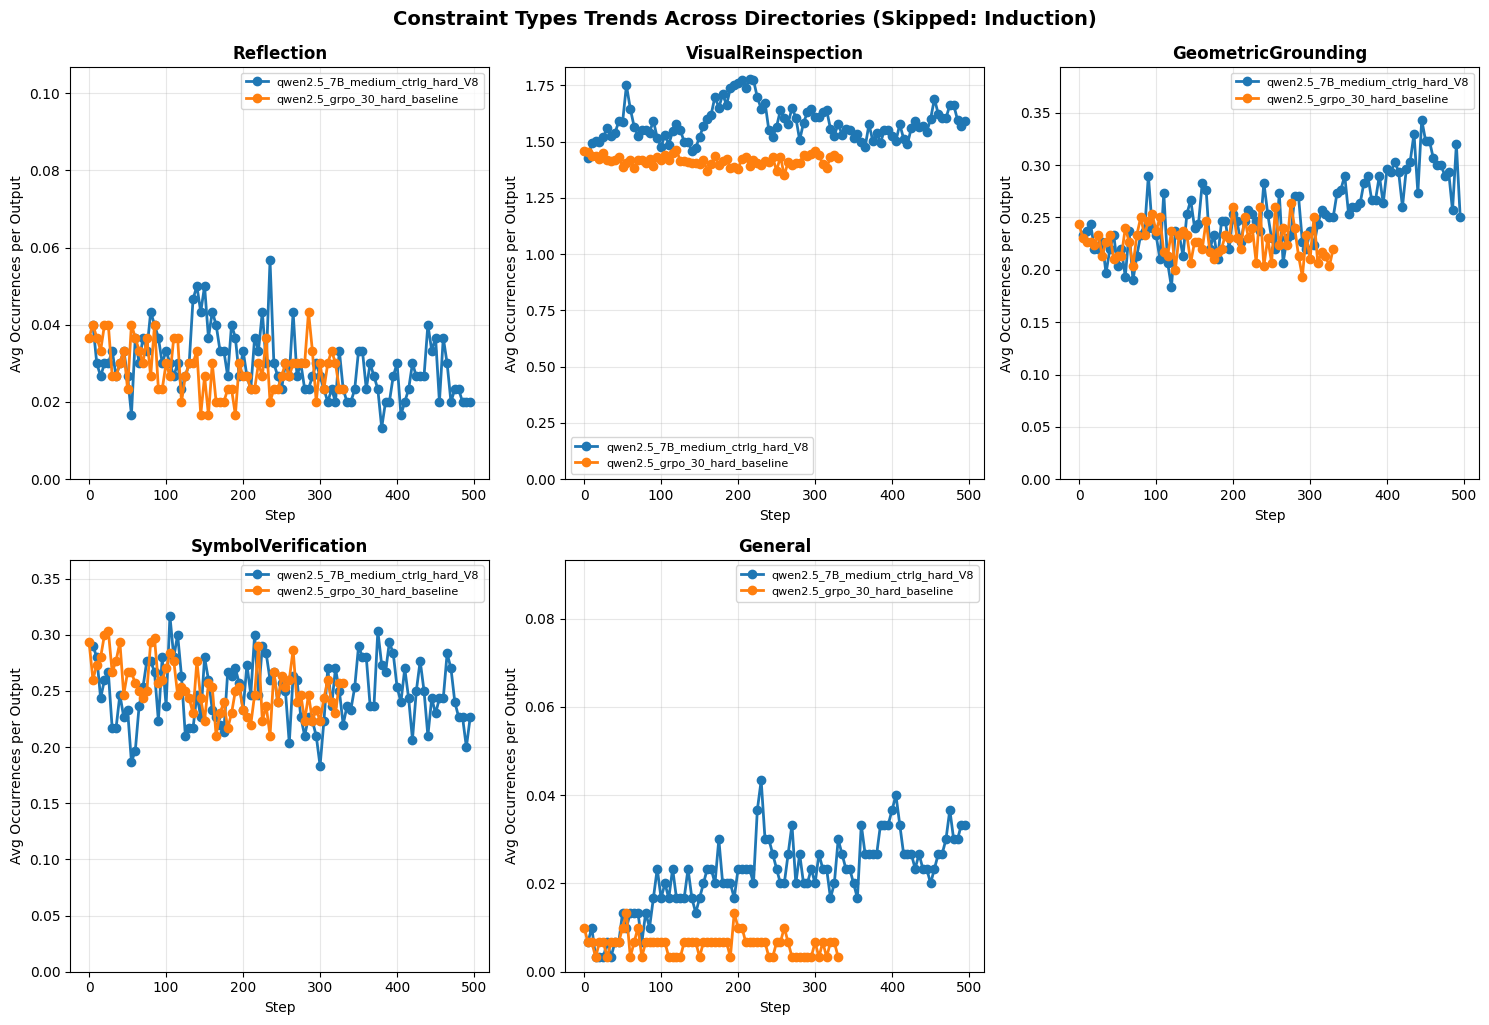

In [10]:
# Example usage of constraint analysis
data_dirs_example = [
    # "../../validation_output/verl/DAPO-DAPO-Baseline-V6",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V4",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V5",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V6",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V7",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V8",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V10",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V12",
    # "../../validation_output/verl/DAPO-DAPO-Baseline-Qwen3-1.7B-V1",
    # "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-1.7B-Base-S60-Boxed-Remote-Soft-C5-Alpha2.0-FixedIS",
]
# constraint_results = analyze_constraints_across_directories(data_dirs_example)

# plot_constraints_trends(
#     constraint_results,
#     skip_types=["Reflection", "DivideAndConquer"],
#     # skip_types=["Backwarding","Backtracking","Induction","Counterfactual"],
#     y_range=(0, 0.1)  # Custom y-axis range
# )

data_dirs_example = [
    # "DAPO-DAPO-Baseline-V6",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V10",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-Boxed-Debug"
    # "DAPO-DAPO-Baseline-V7",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-Boxed-Remote-Soft-C5-Alpha1.0",
    # "test_outputs/qwen2.5_7B_medium_ctrlg_hard_V3",
    "validation_outputs/qwen2.5_7B_medium_ctrlg_hard_V8",
    "validation_outputs/qwen2.5_grpo_30_hard_baseline"
    # "rollout_outputs/qwen2.5_7B_medium_ctrlg_hard_V8",
    # "rollout_outputs/qwen2.5_grpo_30_hard_baseline",
]

# Run the analysis - first analyze the data across directories
constraint_results = analyze_constraints_across_directories(data_dirs_example, file_range_list = [0,10000])


# Then plot the trends - you can skip certain constraint types and set y-axis range
# Example: skip_types=["Reflection", "Counterfactual"] to focus on other constraints
# y_range=(0, 0.2) sets the y-axis from 0 to 0.2 for all subplots
plot_constraints_trends(
    constraint_results,
    skip_types=["Induction"],
    # skip_types=["Backwarding","Backtracking","Induction","Counterfactual"],
    y_range=(0, 0.025)  # Custom y-axis range
)

In [9]:
plot_constraints_trends(
    constraint_results,
    skip_types=["Reflection", "DivideAndConquer"],
    # skip_types=["Backwarding","Backtracking","Induction","Counterfactual"],
    y_range=(0, 0.1)  # Custom y-axis range
)

dict_keys(['Backtracking', 'Backwarding', 'DivideAndConquer', 'Reflection', 'Induction', 'Counterfactual', 'OverthinkingAwareness'])
['Backtracking', 'OverthinkingAwareness', 'Backwarding', 'Induction', 'Counterfactual', 'Backtracking_GoingBack', 'Backtracking_TryAnother']


KeyError: 'Backtracking_GoingBack'

In [4]:
import numpy as np
from typing import List, Tuple, Dict

def find_constraint_positions(text: str, max_position: int = 10240) -> Dict[str, List[int]]:
    """
    Find positions of constraint matches in text.
    Returns dict mapping constraint types to lists of word positions.
    """
    if not text:
        return {}
    
    # Split text into words and track positions
    words = text.split()
    if not words:
        return {}
    
    # Limit to max_position words
    words = words[:max_position]
    
    constraint_positions = {}
    
    # Check each constraint type
    for constraint_type, subtypes in STRICT_COMPILED.items():
        positions = []
        
        for subtype_name, compiled_patterns in subtypes.items():
            # For each sentence, find matches and their approximate word positions
            sentences = _sentences(text)
            current_word_pos = 0
            
            for sentence in sentences:
                sentence_words = sentence.split()
                sentence_start_pos = current_word_pos
                
                # Check if any pattern matches this sentence
                for pattern in compiled_patterns:
                    if pattern.search(sentence):
                        # Find approximate position within sentence
                        match = pattern.search(sentence)
                        if match:
                            # Estimate word position within sentence
                            sentence_prefix = sentence[:match.start()]
                            words_before_match = len(sentence_prefix.split())
                            match_position = sentence_start_pos + words_before_match + 1
                            
                            # Ensure position is within bounds
                            if match_position <= max_position:
                                positions.append(match_position)
                
                current_word_pos += len(sentence_words)
                if current_word_pos > max_position:
                    break
        
        if positions:
            constraint_positions[constraint_type] = positions
    
    return constraint_positions

def analyze_constraint_positions_from_files(file_specs: List[Tuple[str, int]], base_path: str = "./", max_position: int = 10240) -> Dict[str, Dict[str, List[int]]]:
    """
    Analyze constraint positions from multiple files.
    
    Args:
        file_specs: List of (dir_name, step) tuples
        base_path: Base path to directories
        max_position: Maximum word position to consider
    
    Returns:
        Dict mapping file_key to constraint positions
    """
    results = {}
    
    for dir_name, step in tqdm(file_specs, desc="Analyzing constraint positions"):
        file_key = f"{dir_name}_step_{step}"
        file_path = os.path.join(base_path, dir_name, f"{step}.jsonl")
        
        if not os.path.exists(file_path):
            print(f"Warning: File not found: {file_path}")
            continue
        
        all_positions = defaultdict(list)
        
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                try:
                    obj = json.loads(line)
                    output_text = obj.get("output", "")
                    
                    # Find constraint positions in this output
                    positions = find_constraint_positions(output_text, max_position)
                    
                    # Aggregate positions across all outputs
                    for constraint_type, pos_list in positions.items():
                        all_positions[constraint_type].extend(pos_list)
                        
                except json.JSONDecodeError:
                    continue
        
        results[file_key] = dict(all_positions)
    
    return results

def plot_constraint_positions(results: Dict[str, Dict[str, List[int]]], 
                            max_position: int = 10240, 
                            bin_size: int = 100,
                            skip_types: List[str] = None):
    """
    Plot constraint match positions across files.
    
    Args:
        results: Results from analyze_constraint_positions_from_files
        max_position: Maximum position to plot
        bin_size: Size of position bins for histogram
        skip_types: Constraint types to skip
    """
    if skip_types is None:
        skip_types = []
    
    # Get all constraint types
    all_constraint_types = set()
    for file_data in results.values():
        all_constraint_types.update(file_data.keys())
    
    constraint_types = [ct for ct in sorted(all_constraint_types) if ct not in skip_types]
    
    if not constraint_types:
        print("No constraint types to plot")
        return
    
    # Determine subplot layout
    num_constraints = len(constraint_types)
    if num_constraints <= 2:
        rows, cols = 1, num_constraints
    elif num_constraints <= 4:
        rows, cols = 2, 2
    elif num_constraints <= 6:
        rows, cols = 2, 3
    elif num_constraints <= 9:
        rows, cols = 3, 3
    else:
        rows, cols = 3, 4
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if num_constraints == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    # Create bins for positions
    bins = np.arange(0, max_position + bin_size, bin_size)
    
    for i, constraint_type in enumerate(constraint_types):
        ax = axes[i]
        
        # Collect all positions for this constraint type across files
        for file_key, file_data in results.items():
            if constraint_type in file_data:
                positions = file_data[constraint_type]
                if positions:
                    # Create histogram
                    counts, _ = np.histogram(positions, bins=bins)
                    bin_centers = (bins[:-1] + bins[1:]) / 2
                    
                    # Plot as line
                    ax.plot(bin_centers, counts, label=file_key.replace('_', ' '), 
                           marker='o', markersize=3, alpha=0.7)
        
        ax.set_title(f'{constraint_type} Position Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel('Position in Output (words)')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        # Set x-axis limit
        ax.set_xlim(0, max_position)
    
    # Hide unused subplots
    for i in range(num_constraints, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    skip_info = f" (Skipped: {', '.join(skip_types)})" if skip_types else ""
    plt.suptitle(f'Constraint Position Distributions{skip_info}', fontsize=14, fontweight='bold', y=1.02)
    plt.show()

def plot_constraint_positions_heatmap(results: Dict[str, Dict[str, List[int]]], 
                                    max_position: int = 10240, 
                                    bin_size: int = 200,
                                    skip_types: List[str] = None):
    """
    Plot constraint positions as a heatmap showing density across position ranges.
    """
    if skip_types is None:
        skip_types = []
    
    # Get all constraint types and files
    all_constraint_types = set()
    for file_data in results.values():
        all_constraint_types.update(file_data.keys())
    
    constraint_types = [ct for ct in sorted(all_constraint_types) if ct not in skip_types]
    file_keys = sorted(results.keys())
    
    if not constraint_types:
        print("No constraint types to plot")
        return
    
    # Create bins
    bins = np.arange(0, max_position + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    for constraint_type in constraint_types:
        # Create matrix: files x position_bins
        heatmap_data = np.zeros((len(file_keys), len(bin_centers)))
        
        for i, file_key in enumerate(file_keys):
            if constraint_type in results[file_key]:
                positions = results[file_key][constraint_type]
                if positions:
                    counts, _ = np.histogram(positions, bins=bins)
                    heatmap_data[i, :] = counts
        
        # Plot heatmap
        plt.figure(figsize=(12, 6))
        im = plt.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', 
                       extent=[0, max_position, len(file_keys), 0])
        
        plt.colorbar(im, label='Count')
        plt.title(f'{constraint_type} Position Heatmap')
        plt.xlabel('Position in Output (words)')
        plt.ylabel('Files')
        plt.yticks(range(len(file_keys)), [fk.replace('_', ' ') for fk in file_keys])
        plt.tight_layout()
        plt.show()

# Example usage function
def analyze_and_plot_constraint_positions(file_specs: List[Tuple[str, int]], 
                                        base_path: str = "./",
                                        max_position: int = 5000,
                                        bin_size: int = 100,
                                        skip_types: List[str] = None,
                                        plot_heatmap: bool = False):
    """
    Complete pipeline to analyze and plot constraint positions.
    
    Example:
        file_specs = [
            ("DAPO-DAPO-Baseline-V6", 10),
            ("DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V10", 10),
            ("DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11", 10)
        ]
        analyze_and_plot_constraint_positions(file_specs)
    """
    print("Analyzing constraint positions...")
    results = analyze_constraint_positions_from_files(file_specs, base_path, max_position)
    
    print("Creating position distribution plots...")
    plot_constraint_positions(results, max_position, bin_size, skip_types)
    
    if plot_heatmap:
        print("Creating heatmap plots...")
        plot_constraint_positions_heatmap(results, max_position, bin_size, skip_types)
    
    return results

Analyzing constraint positions...


Analyzing constraint positions: 100%|██████████| 1/1 [00:04<00:00,  4.06s/it]


Creating position distribution plots...


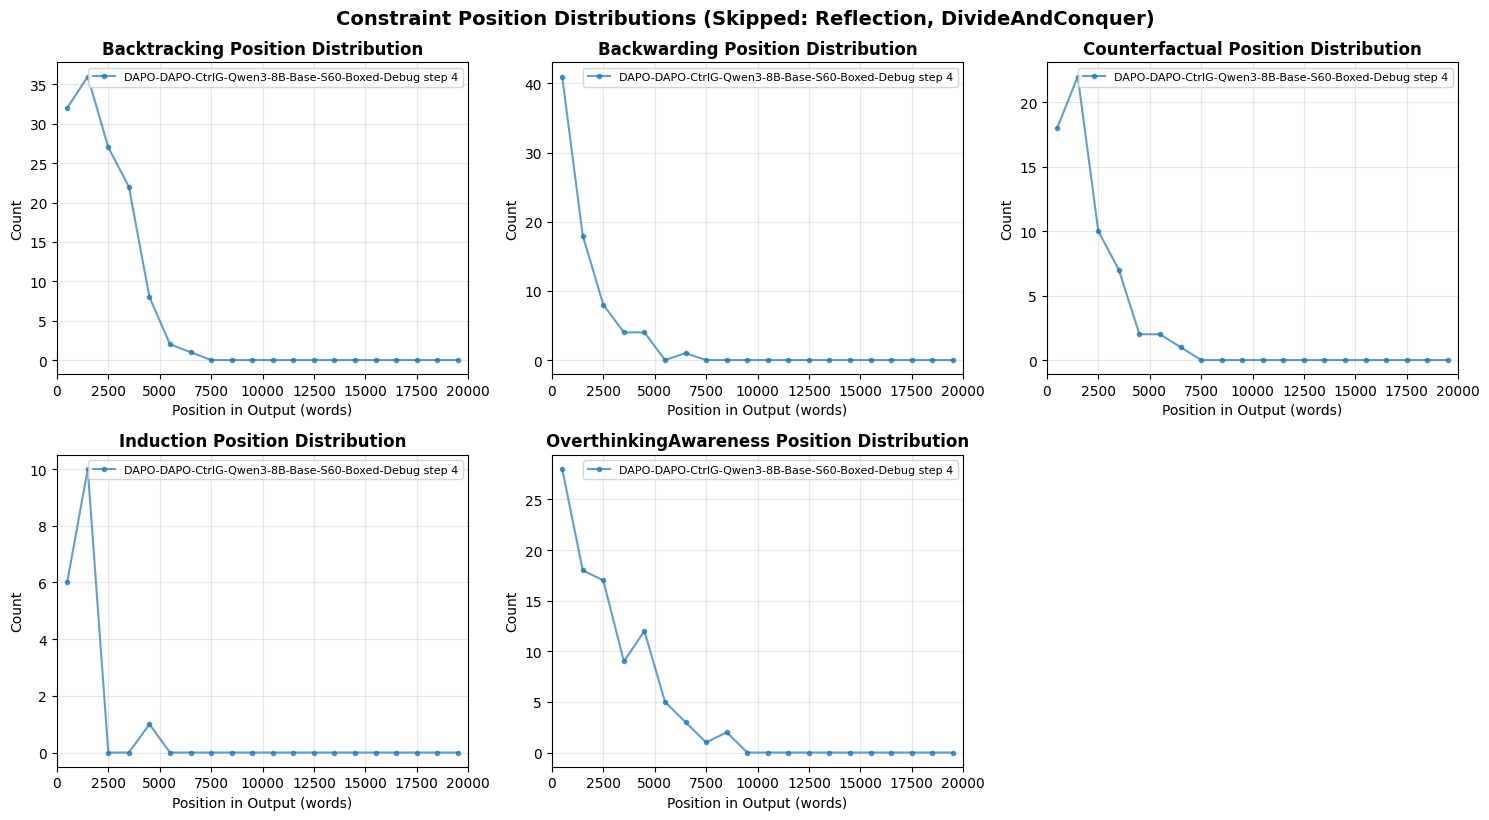

In [6]:
from tqdm import tqdm
# Example usage of constraint position analysis
file_specs_example = [
    # ("../../validation_output/verl/DAPO-DAPO-Baseline-V6", 90),
    # # ("DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V10", 10),
    # ("../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11", 25),
    # ("../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V12", 25),
    # ("DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V12", 4),
    ("DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-Boxed-Debug", 4),
    
]

# Analyze and plot constraint positions
constraint_position_results = analyze_and_plot_constraint_positions(
    file_specs_example,
    base_path="./",
    max_position=20000,  # Focus on first 5000 words
    bin_size=1000,       # Group positions into bins of 200 words
    skip_types=["Reflection", "DivideAndConquer"],  # Skip these types
    plot_heatmap=False   # Also create heatmap plots
)

Analyzing constraint positions...


Analyzing constraint positions: 100%|██████████| 3/3 [00:45<00:00, 15.04s/it]



Creating position distribution plots...


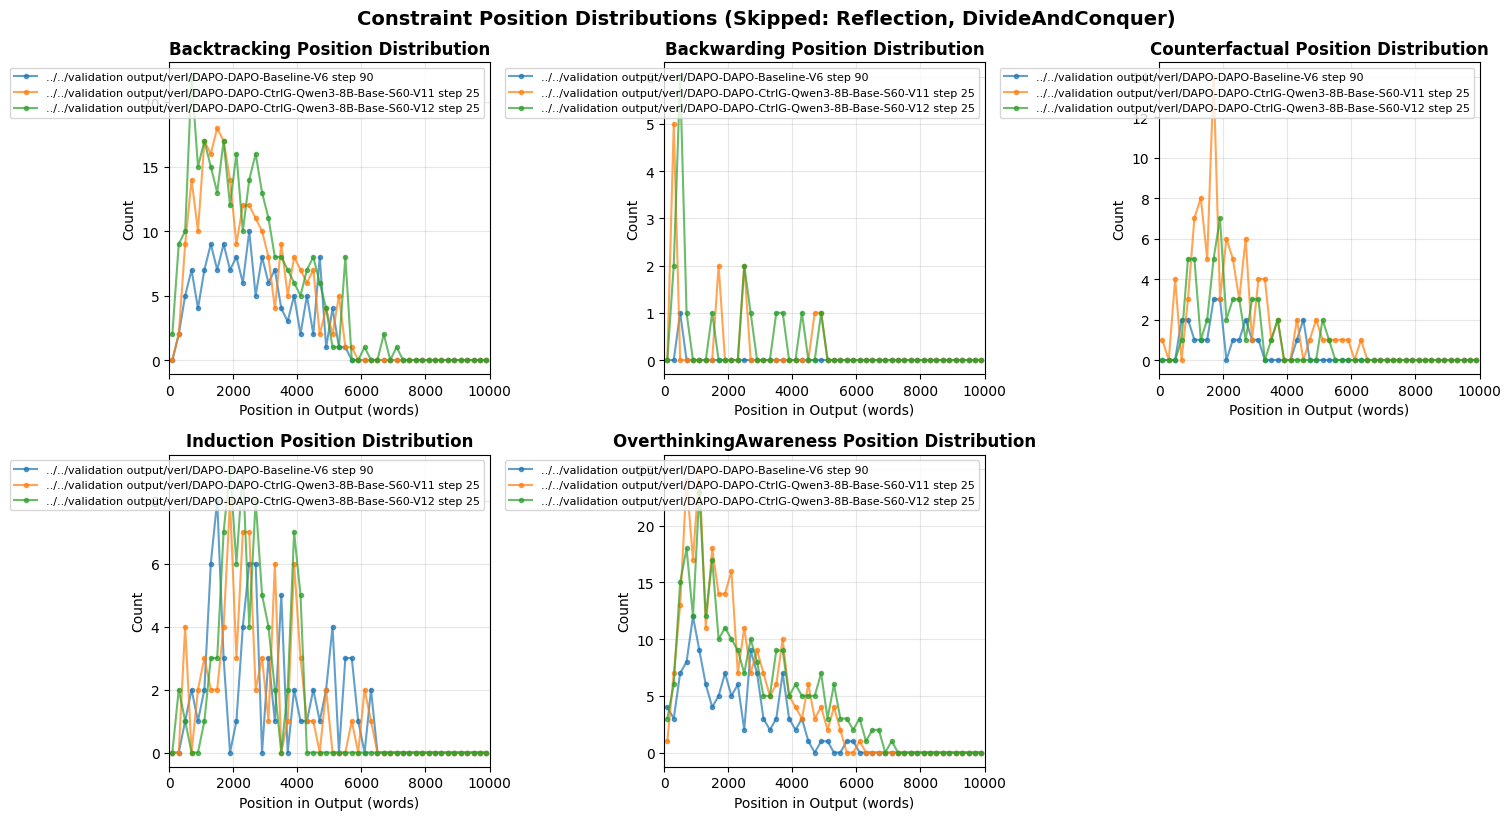

Creating heatmap plots...


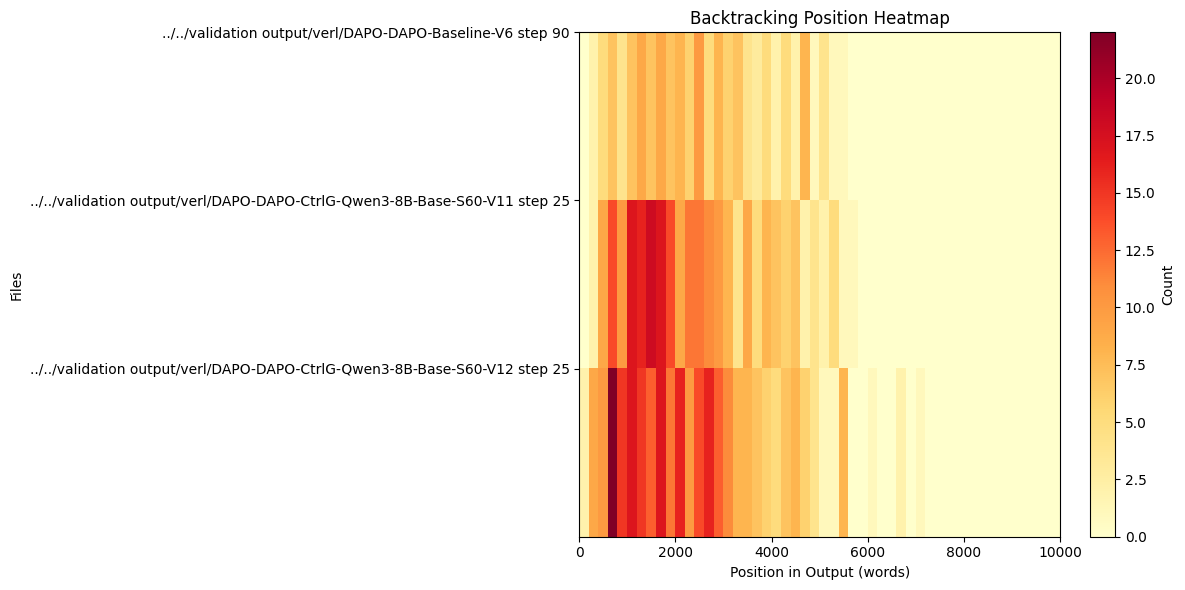

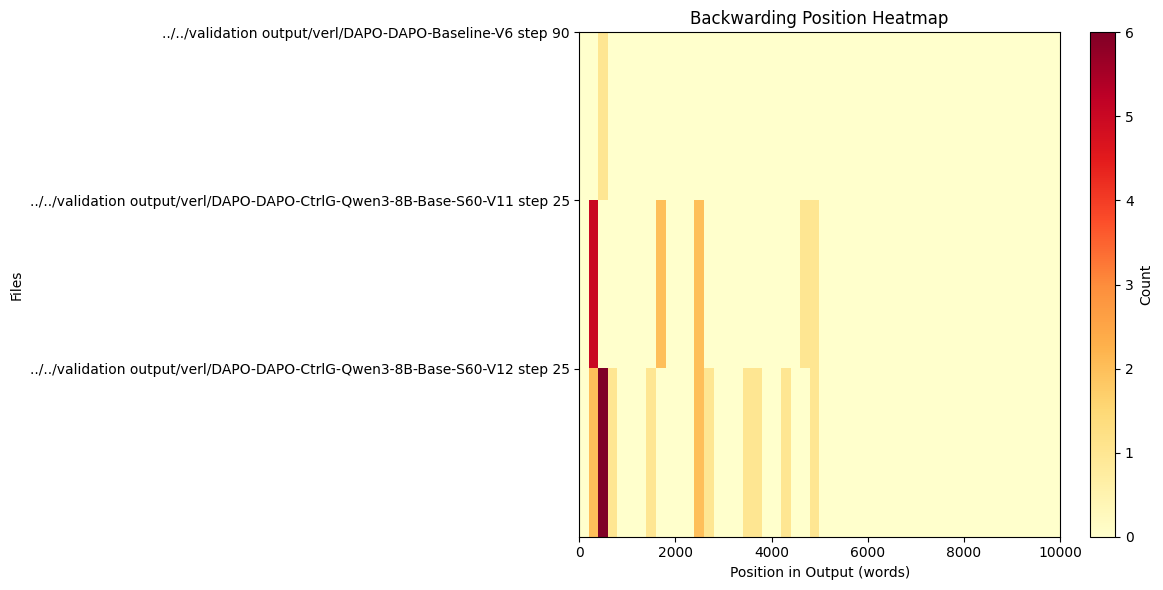

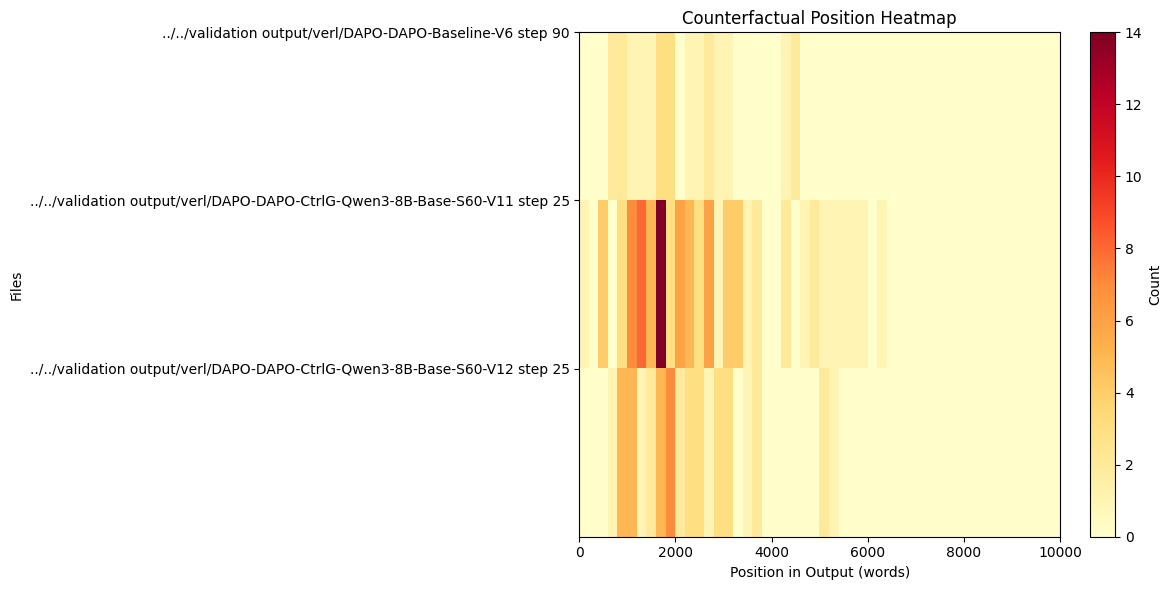

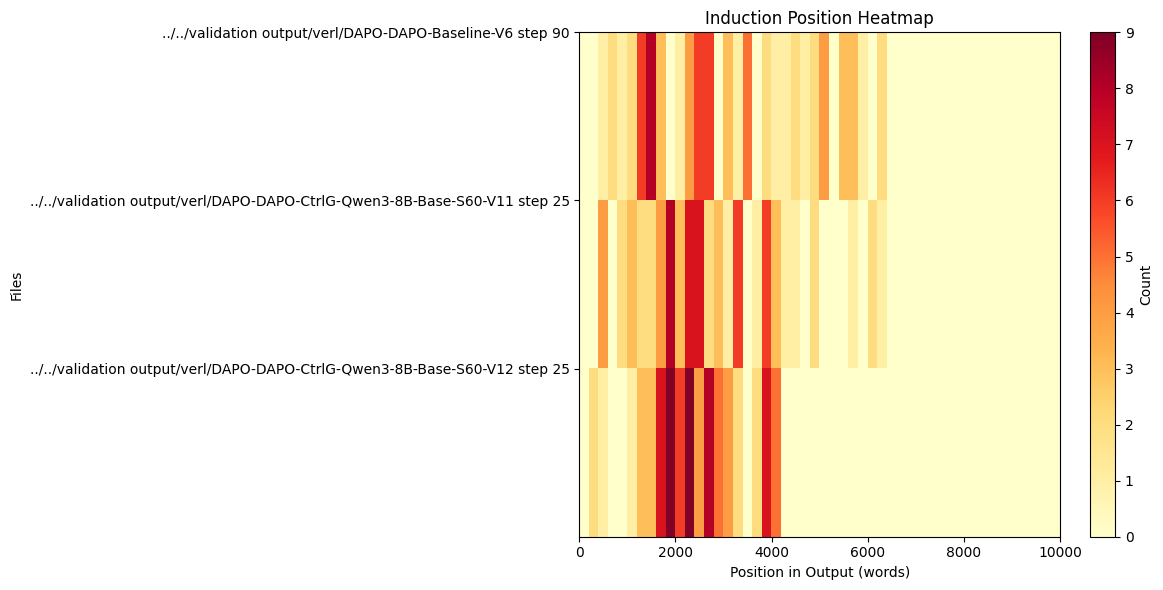

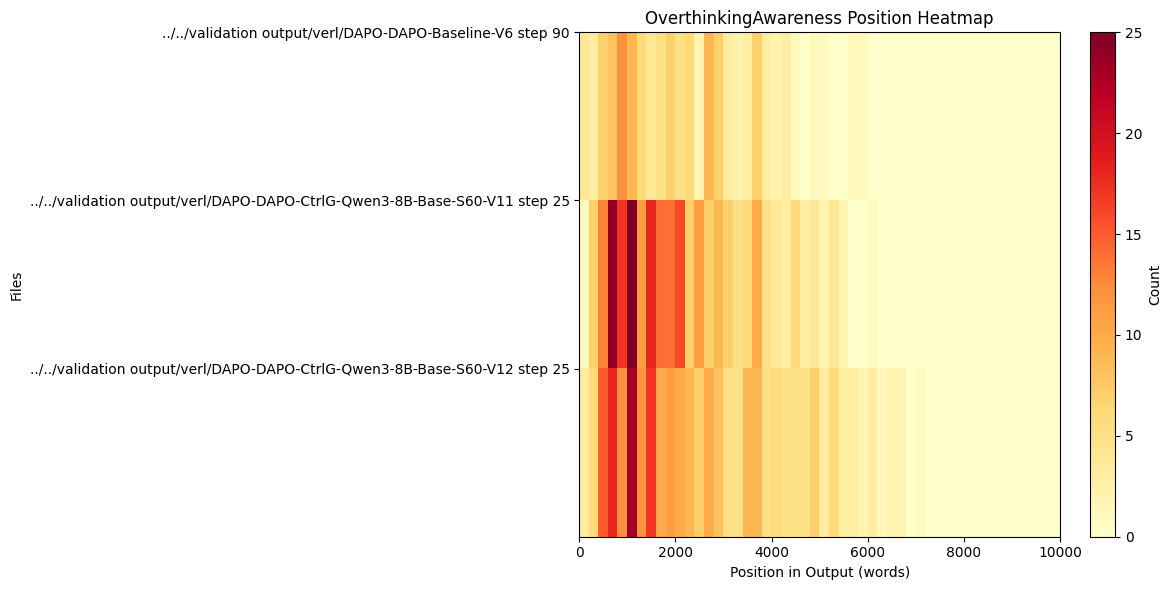

In [16]:
from tqdm import tqdm
# Example usage of constraint position analysis
file_specs_example = [
    ("../../validation_output/verl/DAPO-DAPO-Baseline-V6", 90),
    # ("DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V10", 10),
    ("../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11", 25),
    ("../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V12", 25)
]

# Analyze and plot constraint positions
constraint_position_results = analyze_and_plot_constraint_positions(
    file_specs_example,
    base_path="./",
    max_position=10000,  # Focus on first 5000 words
    bin_size=200,       # Group positions into bins of 200 words
    skip_types=["Reflection", "DivideAndConquer"],  # Skip these types
    plot_heatmap=True   # Also create heatmap plots
)

# Check for repeated answers

In [ ]:
import json
import re
import os
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

def extract_answers(output_text):
    """
    Extract all answers after 'Answer:'.
    """
    answers = re.findall(r"Answer:\s*([^\n\r]*)", output_text)
    return [a.strip() for a in answers if a.strip()]

def extract_answer_terms(output_text):
    """
    Extract all answers after 'Answer:'.
    """
    answers = re.findall(r"\\boxed{([^}]*)}", output_text)
    # answers = re.findall(r"Answer:", output_text)
    return [a.strip() for a in answers if a.strip()]

def has_repeated_answer(output_text, threshold):
    answer_terms = extract_answer_terms(output_text)
    if len(answer_terms) > threshold:
        return True
    return False

def has_consecutive_same_answer(output_text, threshold):
    """
    Stricter: check if the SAME answer appears consecutively.
    """
    answers = extract_answers(output_text)
    num_consecutive = 0
    for i in range(1, len(answers)):
        if answers[i] == answers[i-1]:  # consecutive match
            num_consecutive += 1
            if num_consecutive > threshold:
                return True
    return False

def count_repeated_answers(jsonl_path, threshold_repeat, threshold_consecutive):
    repeated_count = 0
    consecutive_count = 0
    total = 0
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                total += 1
                output_text = data.get("output", "")
                if has_repeated_answer(output_text, threshold_repeat):
                    repeated_count += 1
                if has_consecutive_same_answer(output_text, threshold_consecutive):
                    consecutive_count += 1
            except json.JSONDecodeError:
                print("Skipping invalid JSON line")
                continue
    return repeated_count, consecutive_count, total


Processing files in DAPO-DAPO-Baseline-V6: 100%|██████████| 139/139 [00:34<00:00,  4.07it/s]
Processing files in DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V10: 100%|██████████| 14/14 [00:04<00:00,  2.82it/s]
Processing files in DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11: 100%|██████████| 22/22 [00:06<00:00,  3.22it/s]
Processing files in DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V12: 100%|██████████| 22/22 [00:06<00:00,  3.37it/s]

dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139'])
dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14'])
dict_keys(['1', '2', '3', '4', '5', 

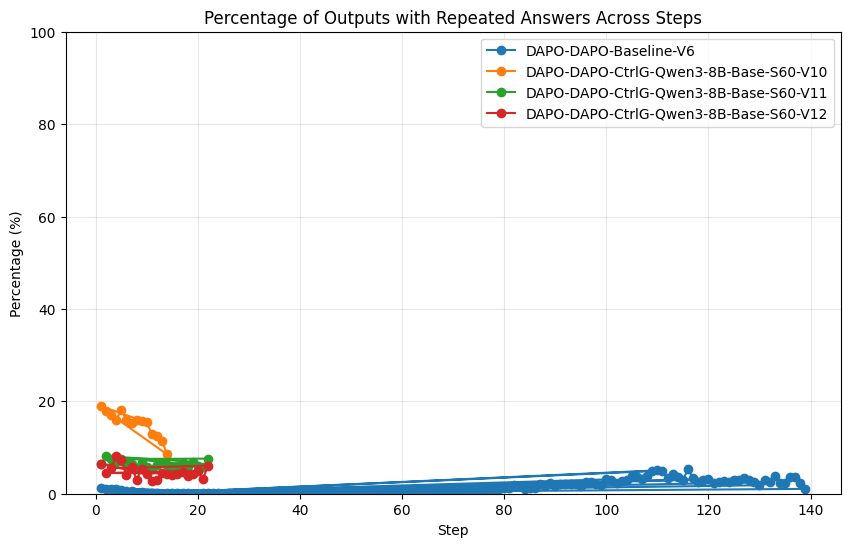

dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139'])
dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14'])
dict_keys(['1', '2', '3', '4', '5', 

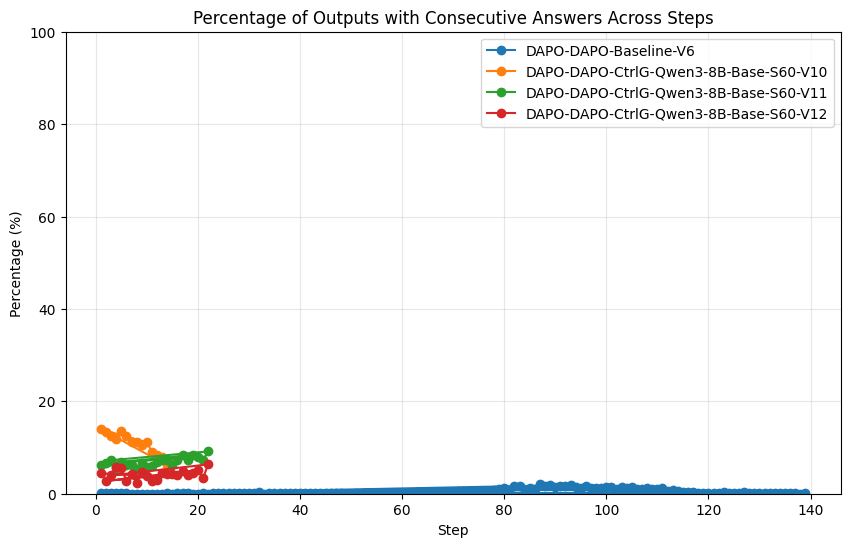

In [7]:
from tqdm import tqdm


data_dirs = [
    "DAPO-DAPO-Baseline-V6",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V5",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V6",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V8",
    # "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V9",
    "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V10",
    "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11",
    "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V12",
]

def plot_repeated_answers_across_dirs(data_dirs, base_path="../../validation_output/verl/", threshold_repeat=10, threshold_consecutive=3, recompute=False):
    results = {}
    for dir_name in data_dirs:
        dir_path = os.path.join(base_path, dir_name)
        file_list = []
        for f in os.listdir(dir_path):
            if f.endswith(".jsonl") and f.replace(".jsonl", "").isdigit():
                file_list.append(int(f.replace(".jsonl", "")))
        dir_results = {}
        # Try to load existing summary if available
        summary_path = os.path.join(dir_path, "repeated_answers_summary.json")
        if (not recompute) and os.path.exists(summary_path):
            try:
                with open(summary_path, "r") as f:
                    dir_results = json.load(f)
            except json.JSONDecodeError:
                print(f"Warning: Could not read existing summary in {summary_path}. Recomputing.")
        
        for file_num in tqdm(sorted(file_list), desc=f"Processing files in {dir_name}"):
            if file_num in dir_results:
                continue  # Skip already processed files
            file_path = os.path.join(dir_path, f"{file_num}.jsonl")
            repeated, consecutive, total = count_repeated_answers(file_path, threshold_repeat, threshold_consecutive)
            # print(type(file_num))
            dir_results[str(file_num)] = {
                "repeated": repeated,
                "consecutive": consecutive,
                "total": total,
                "perc_repeated": (repeated / total * 100) if total else 0,
                "perc_consecutive": (consecutive / total * 100) if total else 0,
            }
        results[dir_name] = dir_results

        # Write the results to a JSON file for reference
        with open(summary_path, "w") as f:
            json.dump(dir_results, f, indent=4)
    
    # Plotting
    for behavior in ["repeated", "consecutive"]:
        plt.figure(figsize=(10, 6))
        for dir_name, dir_results in results.items():
            print(dir_results.keys())
            steps = sorted(dir_results.keys())
            steps = [int(step) for step in steps]
            percents = [dir_results[str(s)][f"perc_{behavior}"] for s in steps]
            plt.plot(steps, percents, marker='o', label=dir_name)
        
        plt.title(f'Percentage of Outputs with {behavior.capitalize()} Answers Across Steps')
        plt.xlabel('Step')
        plt.ylabel('Percentage (%)')
        plt.ylim(0, 100)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

plot_repeated_answers_across_dirs(data_dirs, base_path="./", recompute=True)

# for data_path in data_dirs:
#     repeated, consecutive, total = count_repeated_answers(data_path)
#     print(f"Total examples: {total}")
#     print(f"With repeated answers: {repeated}")
#     print(f"With consecutive repeated answers: {consecutive}")
#     print(f"Percentage (repeated): {repeated / total * 100:.2f}%")
# print(f"Percentage (consecutive): {consecutive / total * 100:.2f}%")

In [10]:
# Plot rm_type

def collect_stats(jsonl_path, threshold_repeat, threshold_consecutive):
    stats = defaultdict(lambda: {"total": 0, "repeated": 0, "consecutive": 0})
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                use_rm = data.get("use_rm", "unknown")
                output_text = data.get("output", "")
                stats[use_rm]["total"] += 1
                if has_repeated_answer(output_text, threshold_repeat):
                    stats[use_rm]["repeated"] += 1
                if has_consecutive_same_answer(output_text, threshold_consecutive):
                    stats[use_rm]["consecutive"] += 1
            except json.JSONDecodeError:
                print("Skipping invalid JSON line")
                continue
    return stats


def collect_constraints_acc_stats(jsonl_path, check_list = ["acc"]):
    stats = defaultdict(lambda: {check: 0 for check in ["total"] + check_list})
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                output_text = data.get("output", "")
                acc = data.get("acc", False)
                pred = data.get("pred", "").strip()
                use_rm_list = [key for key, val in analyze_text_strict(output_text).items() if val > 0]
                for use_rm in use_rm_list:    
                    stats[use_rm]["total"] += 1
                    if "acc" in check_list and acc:
                        stats[use_rm]["acc"] += 1
                    if "overlong" in check_list and pred == "[INVALID]":
                        stats[use_rm]["overlong"] += 1

            except json.JSONDecodeError:
                print("Skipping invalid JSON line")
                continue
    return stats



def plot_stats(stats, map_labels_dict = None):
    labels = list(stats.keys())
    labels.sort()
    totals = [stats[k]["total"] for k in labels]
    repeated = [stats[k]["repeated"] for k in labels]
    consecutive = [stats[k]["consecutive"] for k in labels]

    x = range(len(labels))
    bar_width = 0.25

    plt.figure(figsize=(10,6))
    # plt.bar([i - bar_width for i in x], totals, width=bar_width, label="Total")
    plt.bar(x, [r/t * 100 for r, t in zip(repeated, totals)], width=bar_width, label="Repeated")
    plt.bar([i + bar_width for i in x], [c/t * 100 for c, t in zip(consecutive, totals)], width=bar_width, label="Consecutive")

    if map_labels_dict:
        labels = [map_labels_dict.get(l, l) for l in labels]
    plt.xticks(x, labels)
    plt.xlabel("use_rm")
    plt.ylabel("Count (Percentage)")
    plt.title("Answer Repetition by use_rm")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_stats_constraints_acc(stats, map_labels_dict = None, check_list = ["acc"]):
    labels = list(stats.keys())
    labels.sort()
    totals = [stats[k]["total"] for k in labels]
    
    x = range(len(labels))
    bar_width = 0.25

    plt.figure(figsize=(10,6))

    bar_num = 0
    for check in check_list:
        try:
            print(bar_num, check)
            use_stats = [stats[k][check] for k in labels]

            # plt.bar([i - bar_width for i in x], totals, width=bar_width, label="Total")
            plt.bar([i + bar_width*bar_num for i in x], [r/t * 100 for r, t in zip(use_stats, totals)], width=bar_width, label=check)
            bar_num += 1
        except Exception as e:
            print(f"Error processing check '{check}': {e}")
            continue
        
    if "acc_no_overlong" in check_list:
        try:
            print(bar_num, check)
            acc = [stats[k]["acc"] for k in labels]
            overlong = [stats[k]["overlong"] for k in labels]

            # plt.bar([i - bar_width for i in x], totals, width=bar_width, label="Total")
            plt.bar([i + bar_width*bar_num for i in x], [r/ max(t - o, 1) * 100 for r, o, t in zip(acc, overlong, totals)], width=bar_width, label=check)
            bar_num += 1
        except Exception as e:
            print(f"Error processing check '{check}': {e}")

    if map_labels_dict:
        labels = [map_labels_dict.get(l, l) for l in labels]
    plt.xticks(x, labels)
    plt.xlabel("use_rm")
    plt.ylabel("Count (Percentage)")
    plt.ylim(0, 100)
    plt.title("Answer ACC by use_rm")
    plt.legend()
    plt.tight_layout()
    plt.show()
    


use_rm=1 -> total=51, repeated=0, consecutive=0
use_rm=2 -> total=46, repeated=1, consecutive=0
use_rm=3 -> total=51, repeated=0, consecutive=0
use_rm=4 -> total=54, repeated=1, consecutive=0
use_rm=5 -> total=54, repeated=1, consecutive=0


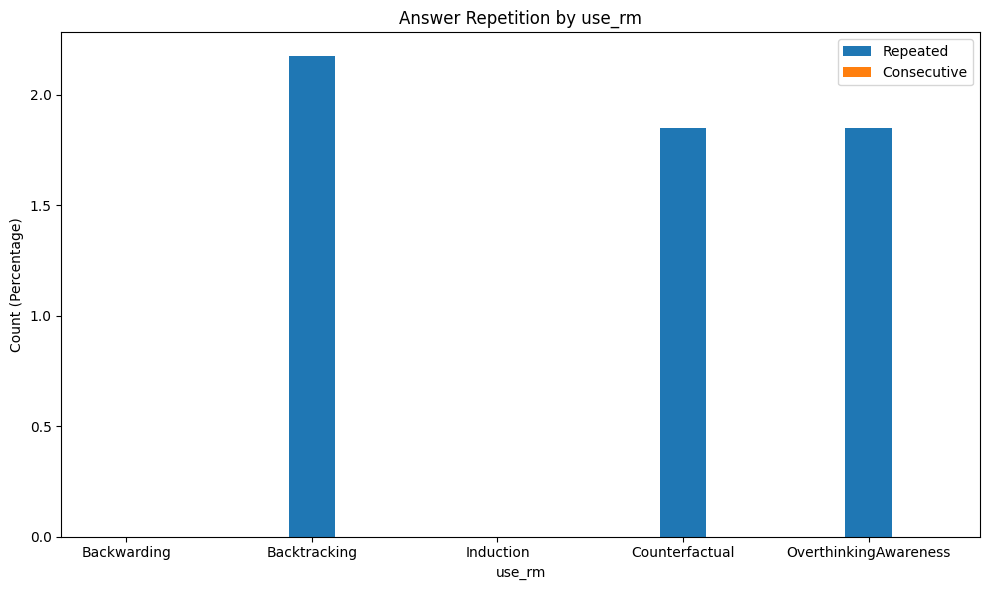

In [ ]:
path = "DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-Boxed-Debug/3.jsonl"  # change to your file
# path = "DAPO-DAPO-Baseline-V6/1.jsonl"  # change to your file
map_labels_dict = {0:"None", 1:"Backwarding", 2:"Backtracking", 3:"Induction", 4:"Counterfactual", 5:"OverthinkingAwareness"}
stats = collect_stats(path, threshold_repeat=10, threshold_consecutive=3)

# Print raw numbers
for k, v in stats.items():
    print(f"use_rm={k} -> total={v['total']}, repeated={v['repeated']}, consecutive={v['consecutive']}")

# Plot chart
plot_stats(stats, map_labels_dict=map_labels_dict)

0 acc
1 overlong
2 acc_no_overlong
Error processing check 'acc_no_overlong': 'acc_no_overlong'
2 acc_no_overlong


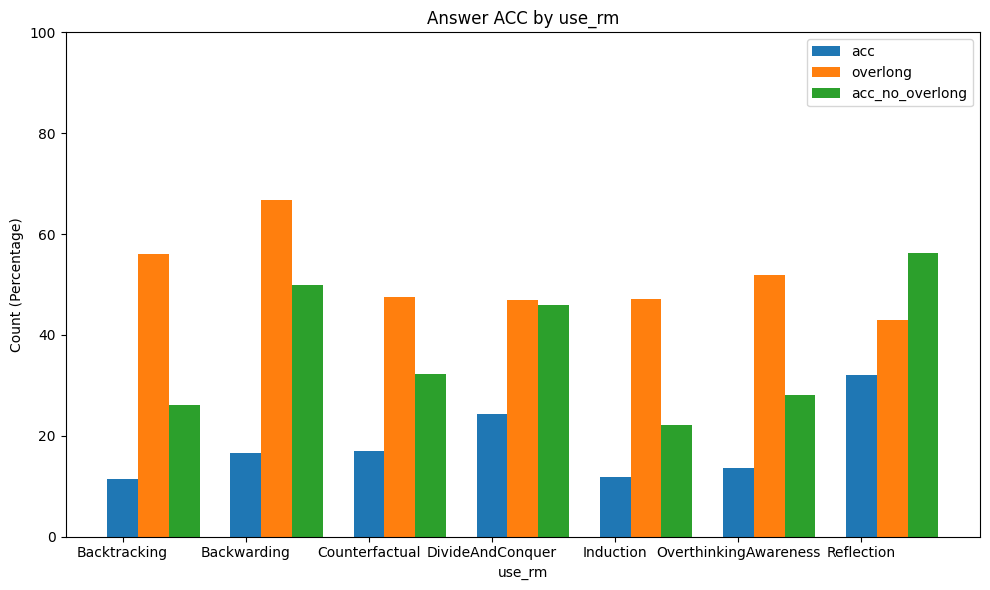

In [43]:
path = "../../validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11/30.jsonl"  # change to your file
# path = "DAPO-DAPO-Baseline-V6/1.jsonl"  # change to your file
stats_constraints_acc = collect_constraints_acc_stats(path, check_list=["acc", "overlong"])

# Print raw numbers
# for k, v in stats_constraints_acc.items():
#     print(f"use_rm={k} -> total={v['total']}, stats={v['stats']}")

# Plot chart
plot_stats_constraints_acc(stats_constraints_acc, check_list=["acc", "overlong", "acc_no_overlong"])

0 acc
1 overlong
2 acc_no_overlong
Error processing check 'acc_no_overlong': 'acc_no_overlong'
2 acc_no_overlong


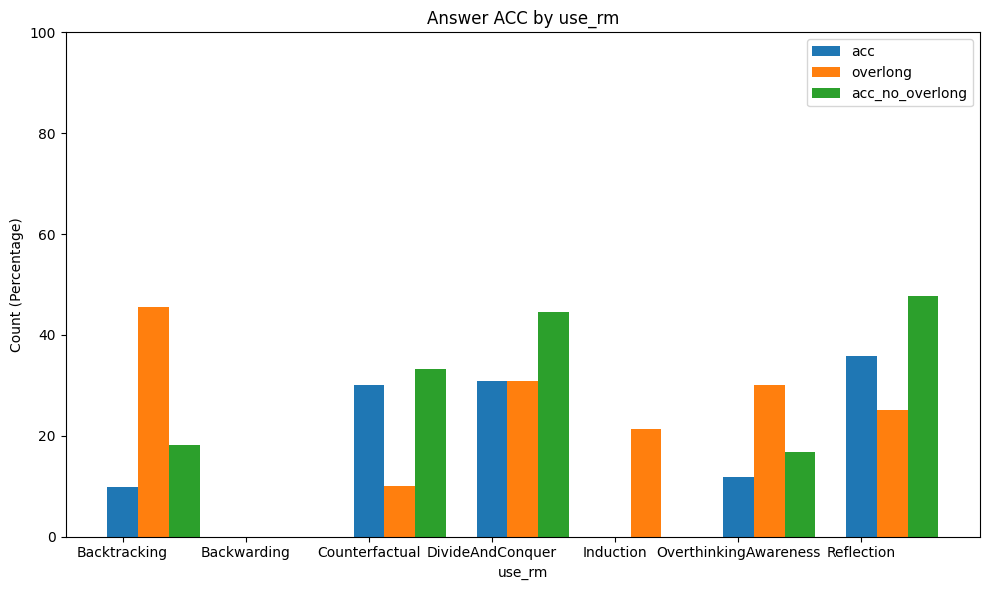

In [42]:
path = "../../validation_output/verl/DAPO-DAPO-Baseline-V6/90.jsonl"  # change to your file
# path = "DAPO-DAPO-Baseline-V6/1.jsonl"  # change to your file
stats_constraints_acc = collect_constraints_acc_stats(path, check_list=["acc", "overlong"])

# Print raw numbers
# for k, v in stats_constraints_acc.items():
#     print(f"use_rm={k} -> total={v['total']}, stats={v['stats']}")

# Plot chart
plot_stats_constraints_acc(stats_constraints_acc, check_list=["acc", "overlong", "acc_no_overlong"])

In [ ]:
has_consecutive_same_answer(out, 3)
def extract_answers_new(output_text):
    """
    Extract all answers after 'Answer:'.
    """
    answers = re.findall(r"Answer:", output_text)
    return [a.strip() for a in answers if a.strip()]
extract_answers_new(out)

In [45]:
from hashlib import md5

def compare_dev_scores(file_a, file_b):
    """
    Compare dev scores between two JSONL files.
    """
    def load_scores(file_path):
        scores = []
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                scores.append(data)
        return scores
    
    scores_a = load_scores(file_a)
    scores_b = load_scores(file_b)
    
    
    def get_results(scores):    
        results = {} # input: score
        for data in scores:
            key = md5(data["input"].encode()).hexdigest()
            metric = {
                "correct": 0,
                "invalid": 0,
            }
            if not key in results:
                results[key] = metric
            results[key]["correct"] += data["acc"]
            results[key]["invalid"] += data["pred"] == "[INVALID]"
        return results
    
    results_a = get_results(scores_a)
    results_b = get_results(scores_b)
    print(results_a)
    correct_a = 0
    correct_b = 0
    total = 0
    n = 32
    
    for key in results_a.keys():
        invalid_num = max(results_a[key]["invalid"], results_b[key]["invalid"])
        use_num = n - invalid_num
        total += use_num
        correct_a += min(use_num, results_a[key]["correct"])
        correct_b += min(use_num, results_b[key]["correct"])
        
    print(f"File A: {file_a}, Correct: {correct_a}, Total: {total}, Accuracy: {correct_a/total:.4f}")
    print(f"File B: {file_b}, Correct: {correct_b}, Total: {total}, Accuracy: {correct_b/total:.4f}")

In [47]:
compare_dev_scores(
    "/local1/ponienkung/Ctrl-R/LIMR_verl/validation_output/verl/DAPO-DAPO-Baseline-V6/90.jsonl", 
    # "/local1/ponienkung/Ctrl-R/LIMR_verl/validation_output/verl/DAPO-DAPO-Baseline-V6/100.jsonl", 
    # "/local1/ponienkung/Ctrl-R/LIMR_verl/validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V8/90.jsonl",
    # "/local1/ponienkung/Ctrl-R/LIMR_verl/validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V11/20.jsonl",
    "/local1/ponienkung/Ctrl-R/LIMR_verl/validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V12/30.jsonl",
    # "/local1/ponienkung/Ctrl-R/LIMR_verl/validation_output/verl/DAPO-DAPO-CtrlG-Qwen3-8B-Base-S60-V4/25.jsonl",
)

{'bfc9297efeab6c4f78c70247280caaaa': {'correct': 29, 'invalid': 1}, '0f26b7490f3dc2a6e582255e1c23a386': {'correct': 30, 'invalid': 1}, '730cec0575242aeddbe83ca7298aaf18': {'correct': 23, 'invalid': 2}, '1209415a8e50d10413eec7ab2c3409af': {'correct': 7, 'invalid': 9}, '2a29ab0f2c7ad106bd039138f262d02c': {'correct': 5, 'invalid': 12}, 'deae337f5c940ad68014156dc330a094': {'correct': 21, 'invalid': 5}, 'aa3afc8cd0918d3a4a3d93f7627584be': {'correct': 0, 'invalid': 7}, 'ff6edb91b34630f035eebf4cd59a2fef': {'correct': 8, 'invalid': 11}, 'ef3e91169f61812bd2a260c996576dd5': {'correct': 3, 'invalid': 10}, 'd8407ca8dcfa9fc0535877efc4f16e29': {'correct': 2, 'invalid': 8}, 'a1a3fde677b7e6687b5c141566b07279': {'correct': 16, 'invalid': 12}, '3664483e75f0247b89d01747b47cf76f': {'correct': 0, 'invalid': 28}, '6111adf9ddb3db07cabfbd779be538ad': {'correct': 0, 'invalid': 4}, '40db3374bc3c2a238656076257808d73': {'correct': 0, 'invalid': 31}, '078bd6919ed8fa0f746ce33a1e73f8d2': {'correct': 2, 'invalid': 28